# Xenium HBC1 · V1004 independent-view niches

C is local cell-type composition; I is local directed pairwise CCC. The two fixed-parameter NMF fits are independent. Hungarian alignment only renames I factors; every observed aligned (C, I) assignment becomes a final niche. Agreement measures label overlap, not biological identity.


## 1. Imports and fixed exploratory settings

In [1]:
import sys
from pathlib import Path
ROOT=Path('/data1/xueshuailin/CCC_Phe_Niche')
SOURCE=Path('/home/xueshuailin/CCC_Phe/V1004/src')
if str(SOURCE) in sys.path: sys.path.remove(str(SOURCE))
sys.path.insert(0,str(SOURCE))
import numpy as np, pandas as pd, anndata as ad, matplotlib.pyplot as plt, torch
from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown
from scipy.spatial import cKDTree
from phenoniche.v1001.neighborhoods import build_neighborhoods
from phenoniche.v1002.lr_atlas import load_lr_atlas, LRAtlas
from phenoniche.v1002.simulation_cells import _side_expression, aggregate_pairwise_ccc
from phenoniche.v1002.final_model import fit_balanced
from phenoniche.v1004.late_fusion import align_partitions, apply_alignment, build_joint_niches
import inspect
assert all(Path(inspect.getfile(fn)).resolve().is_relative_to(SOURCE)
           for fn in (build_neighborhoods, load_lr_atlas, aggregate_pairwise_ccc, fit_balanced, align_partitions))
N_NEIGHBORS=30
SIGMA_UM=20.0  # fixed Gaussian distance scale in official micron coordinates
K_NICHE=8
SEED=40700
DEVICE='cuda:0' if torch.cuda.is_available() else 'cpu'


## 2. Processed cells and official labels

In [2]:
path=ROOT/'data/Xenium_HBC1/processed/HBC1_Xenium_processed.h5ad'
adata=ad.read_h5ad(path)
assert adata.uns['dataset']=='Xenium_FFPE_Human_Breast_Cancer_Rep1'
assert adata.obs.cell_id.is_unique and adata.obs_names.equals(pd.Index(adata.obs.cell_id))
assert np.isfinite(adata.obsm['spatial']).all()
coordinates=adata.obsm['spatial'].astype(np.float32)
label_categories=sorted(adata.obs.cell_type_coarse.unique())
cell_type=pd.Categorical(adata.obs.cell_type_coarse,categories=label_categories).codes.astype(np.int16)
assert (cell_type>=0).all()
T=len(label_categories); N=adata.n_obs
ranges=f"x {coordinates[:,0].min():.0f}–{coordinates[:,0].max():.0f} µm; y {coordinates[:,1].min():.0f}–{coordinates[:,1].max():.0f} µm"
display(pd.DataFrame([{'Cells':N,'Genes':adata.n_vars,'Cell types':T,'Coordinate range':ranges}]))
display(adata.obs.cell_type_coarse.value_counts().rename_axis('Official cell type').to_frame('n_cells'))


,Cells,Genes,Cell types,Coordinate range
0,166363,313,20,x 2–7523 µm; y 3–5474 µm


,n_cells
Official cell type,
Stromal,41422
Invasive_Tumor,34374
DCIS_1,12923
DCIS_2,11683
Macrophages_1,11174
Endothelial,8931
CD4+_T_Cells,8453
Unlabeled,7137
Myoepi_ACTA2+,7078


## 3. Official cell-type spatial map

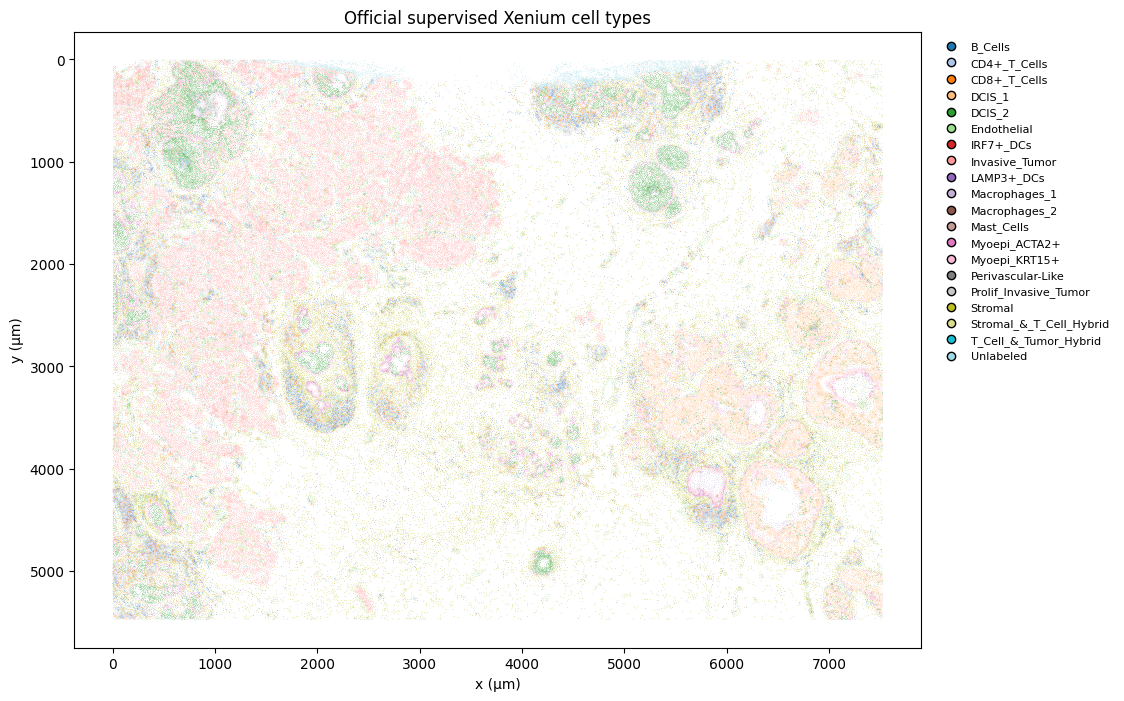

In [3]:
type_colors=plt.get_cmap('tab20',T)(np.arange(T))
fig,ax=plt.subplots(figsize=(11,8))
ax.scatter(coordinates[:,0],coordinates[:,1],c=type_colors[cell_type],s=.24,linewidths=0,rasterized=True)
ax.set(xlabel='x (µm)',ylabel='y (µm)',title='Official supervised Xenium cell types')
ax.set_aspect('equal'); ax.invert_yaxis()
handles=[plt.Line2D([0],[0],marker='o',color='none',markerfacecolor=type_colors[i],markersize=6,label=name) for i,name in enumerate(label_categories)]
ax.legend(handles=handles,bbox_to_anchor=(1.01,1),loc='upper left',frameon=False,fontsize=8)
plt.show()


## 4. Fixed V1004 neighborhoods and composition

In [4]:
neighborhoods=build_neighborhoods(coordinates,k=N_NEIGHBORS,sigma=SIGMA_UM)
members=neighborhoods.indices.reshape(N,N_NEIGHBORS)
anchor_weights=neighborhoods.weights.reshape(N,N_NEIGHBORS).astype(np.float32)
BATCH=256
C,_,opportunity=aggregate_pairwise_ccc(
    coordinates,cell_type,np.zeros((N,1),dtype=np.float32),np.zeros((N,1),dtype=np.float32),
    T,sigma=SIGMA_UM,members=members,anchor_weights=anchor_weights,
    batch_size=BATCH,device=DEVICE,compute_signal=False,
)
pair_support=(opportunity>0).sum(0)
assert np.allclose(C.sum(1),1,atol=1e-5)


## 5. Measurable LR atlas and outcome-blind CCC mask

In [5]:
atlas=load_lr_atlas(str(SOURCE.parent/'data/commuspace_human_lr_atlas.tsv'))
panel=set(adata.var_names.str.upper())
measurable=tuple(row for row in atlas.interactions if all(g in panel for g in row.ligand_components+row.receptor_components))
measurable_atlas=LRAtlas(measurable,{'n_raw_lr':len(atlas),'n_unique_lr':len(measurable)},atlas.source_path)
if not measurable: raise RuntimeError('No fully measurable LR interaction in the Xenium panel')
lr_genes=tuple(sorted({g for row in measurable for g in row.ligand_components+row.receptor_components}))
expression=np.column_stack([adata[:,gene].X.toarray().ravel() for gene in lr_genes]).astype(np.float32)
ligand,receptor=_side_expression(expression,lr_genes,measurable_atlas)
coverage_l=np.stack([(ligand[cell_type==t]>0).mean(0) for t in range(T)])
coverage_r=np.stack([(receptor[cell_type==t]>0).mean(0) for t in range(T)])
coverage=((coverage_l[:,None,:]>=.10)&(coverage_r[None,:,:]>=.10)).reshape(T*T,-1)
supported=pair_support>=max(20,int(np.ceil(.01*N)))
feature_mask=(coverage&supported[:,None]).reshape(-1)
final_ccc=int(feature_mask.sum())
display(pd.DataFrame([{'Panel genes':adata.n_vars,'Atlas LR pairs':len(atlas),
                       'Fully measurable LR pairs':len(measurable),'Final directed CCC features':final_ccc}]))
if len(measurable)<100:
    display(Markdown('**WARNING:** Xenium 313-gene panel provides limited LR coverage; the following niche result is exploratory.'))
if final_ccc==0: raise RuntimeError('No directed CCC feature passed the fixed outcome-blind filter')


,Panel genes,Atlas LR pairs,Fully measurable LR pairs,Final directed CCC features
0,313,8408,40,3344


**WARNING:** Xenium 313-gene panel provides limited LR coverage; the following niche result is exploratory.

## 6. Chunked directed CCC from the same neighborhoods

In [6]:
I=np.empty((N,final_ccc),dtype=np.float32)
_,I,signal_opportunity=aggregate_pairwise_ccc(
    coordinates,cell_type,ligand,receptor,T,sigma=SIGMA_UM,
    members=members,anchor_weights=anchor_weights,feature_mask=feature_mask,
    batch_size=BATCH,device=DEVICE,communication_out=I,
)
assert np.allclose(opportunity,signal_opportunity,rtol=1e-5,atol=1e-6)
del signal_opportunity
assert I.shape==(N,final_ccc) and np.isfinite(I).all()


## 7. Independent C-only and I-only NMF (K=8)


In [7]:
fit_C=fit_balanced({'HC':C},seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
fit_I=fit_balanced({'HI':I},seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
W_C=np.maximum(fit_C.W.numpy(),0)
W_I=np.maximum(fit_I.W.numpy(),0)
W_C/=np.maximum(W_C.sum(1,keepdims=True),1e-12)
W_I/=np.maximum(W_I.sum(1,keepdims=True),1e-12)
c_labels=W_C.argmax(1)
i_labels=W_I.argmax(1)
assert W_C.shape==W_I.shape==(N,K_NICHE)


## 8. Hungarian label alignment and overlap quality

Alignment permutes only I labels and columns; it does not change cell assignments.


In [8]:
alignment=align_partitions(c_labels,i_labels,K_NICHE)
r_aligned,W_I_aligned=apply_alignment(i_labels,W_I,alignment)
untied=(W_I==W_I.max(1,keepdims=True)).sum(1)==1
assert np.array_equal(r_aligned[untied],W_I_aligned.argmax(1)[untied])
print(f'I-view argmax ties (labels retain their original tie-break): {N-int(untied.sum())}')
assert np.array_equal(np.sort(np.bincount(r_aligned,minlength=K_NICHE)),
                      np.sort(np.bincount(i_labels,minlength=K_NICHE)))
mapping_table=pd.DataFrame(alignment.mapping)
display(mapping_table)
display(pd.DataFrame({'C factor':np.arange(K_NICHE),
                      'agreement fraction':alignment.per_c_agreement}))
print(f'Overall agreement after alignment: {alignment.overall_agreement:.4f}')


I-view argmax ties (labels retain their original tie-break): 1344


,C_factor,original_I_factor,matched_cell_count,overlap_fraction
0,0,6,13442,0.263579
1,1,0,35926,0.791984
2,2,4,929,0.119856
3,3,7,1134,0.173051
4,4,1,12233,0.666794
5,5,2,11436,0.870784
6,6,5,13043,0.644799
7,7,3,253,0.063377


,C factor,agreement fraction
0,0,0.263579
1,1,0.791984
2,2,0.119856
3,3,0.173051
4,4,0.666794
5,5,0.870784
6,6,0.644799
7,7,0.063377


Overall agreement after alignment: 0.5313


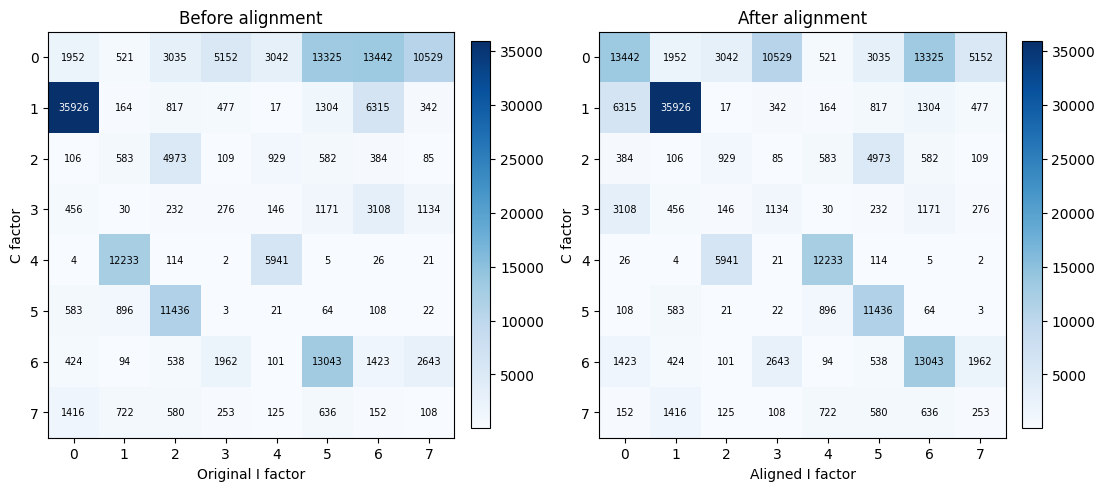

In [9]:
fig,axes=plt.subplots(1,2,figsize=(11,4.8),constrained_layout=True)
for ax,matrix,title,xlabel in zip(
    axes,(alignment.before,alignment.after),
    ('Before alignment','After alignment'),
    ('Original I factor','Aligned I factor')):
    image=ax.imshow(matrix,cmap='Blues',aspect='equal')
    ax.set(title=title,xlabel=xlabel,ylabel='C factor',
           xticks=np.arange(K_NICHE),yticks=np.arange(K_NICHE))
    for row in range(K_NICHE):
        for col in range(K_NICHE):
            ax.text(col,row,str(matrix[row,col]),ha='center',va='center',fontsize=7,
                    color='white' if matrix[row,col]>matrix.max()/2 else 'black')
    fig.colorbar(image,ax=ax,fraction=.046,pad=.04)
plt.show()


## 9. Number only observed joint states

Concordant states precede discordant states. The mapping table records internal provenance; maps display only Final Niche IDs.


In [10]:
final_niche,joint_mapping=build_joint_niches(c_labels,r_aligned,K_NICHE)
final_mapping_table=pd.DataFrame(joint_mapping)
display(final_mapping_table)
print(f'Observed joint states / final niches: {len(joint_mapping)}')
assert final_mapping_table['n_cells'].sum()==N


,final_niche_id,C_state,I_state_aligned,n_cells,fraction,concordant
0,Final Niche 1,0,0,13442,0.080799,True
1,Final Niche 2,1,1,35926,0.215949,True
2,Final Niche 3,2,2,929,0.005584,True
3,Final Niche 4,3,3,1134,0.006816,True
4,Final Niche 5,4,4,12233,0.073532,True
...,...,...,...,...,...,...
59,Final Niche 60,7,2,125,0.000751,False
60,Final Niche 61,7,3,108,0.000649,False
61,Final Niche 62,7,4,722,0.004340,False
62,Final Niche 63,7,5,580,0.003486,False


Observed joint states / final niches: 64


## 10. Spatial maps


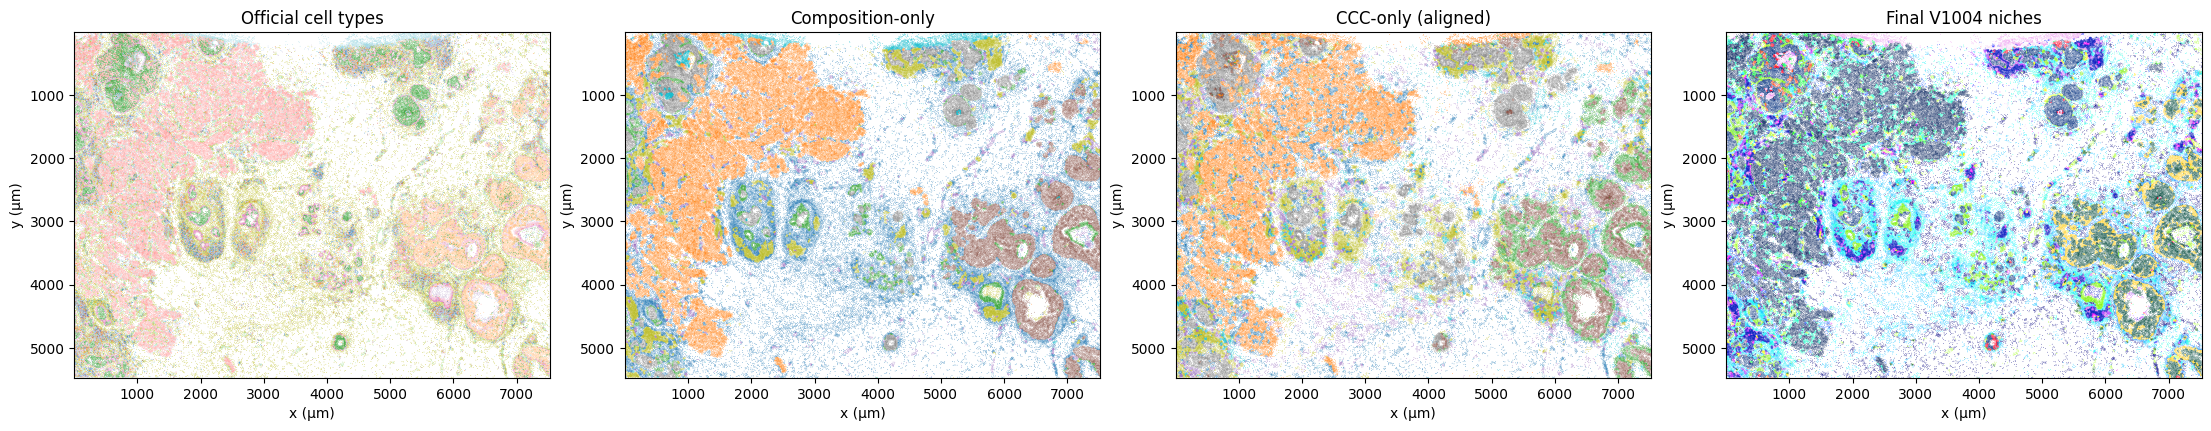

In [11]:
single_colors=plt.get_cmap('tab10',K_NICHE)(np.arange(K_NICHE))
final_colors=plt.get_cmap('gist_ncar',len(joint_mapping))(np.arange(len(joint_mapping)))
spatial_panels=[('Official cell types',type_colors[cell_type]),
                ('Composition-only',single_colors[c_labels]),
                ('CCC-only (aligned)',single_colors[r_aligned]),
                ('Final V1004 niches',final_colors[final_niche])]
fig,axes=plt.subplots(1,4,figsize=(22,5.8),constrained_layout=True)
for ax,(title,colors) in zip(axes,spatial_panels):
    ax.scatter(coordinates[:,0],coordinates[:,1],c=colors,s=.24,linewidths=0,rasterized=True)
    ax.set(title=title,xlabel='x (µm)',ylabel='y (µm)')
    ax.set_xlim(coordinates[:,0].min(),coordinates[:,0].max())
    ax.set_ylim(coordinates[:,1].max(),coordinates[:,1].min())
    ax.set_aspect('equal')
plt.show()
